## Run a pipeline adding a custom algorithm

This process will run the entire pipeline described in a configuration file and will add a custom algorithm to it

## Import dependencies

In [5]:
%load_ext autoreload
%autoreload 2
from paidiverpy.pipeline import Pipeline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Instantiate the Pipeline class

When you instantiate the pipeline class, it will install some dependencies described in the configuration file that are necessary for the custom algorithm

In [6]:
pipeline = Pipeline(config_file_path="../config_files/config_custom_algorithm.yml")

This occurs because of the following step that you added in the conf file:

```
steps:
    ...

  - custom:
      name: "min_max_data"
      file_path: "/mnt/noc/code/paidiver/paidiverpy/examples/custom_algorithms/custom_algorithm_example.py"
      class_name: "MyMethod"
      dependencies:
        - "scikit-learn"
      params:
        feature_range: (0, 1)
```

In this case, you are saying that you need to install scikit-learn to use the custom algorithm

In [7]:
pipeline.config

{
    "general": {
        "name": "raw",
        "step_name": "open",
        "sample_data": "benthic_csv",
        "input_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/images",
        "metadata_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv",
        "metadata_type": "CSV_FILE",
        "image_type": "PNG",
        "append_data_to_metadata": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv",
        "is_remote": false,
        "output_is_remote": false,
        "output_path": "output",
        "n_jobs": 1,
        "client": null,
        "track_changes": true,
        "rename": "datetime",
        "sampling": [
            {
                "name": "sampling",
                "step_name": "sampling",
                "test": false,
                "mode": "percent",
                "params": {
                    "value": 0.1,
                    "raise_error": false
                }
            }
     

In [8]:
# See the pipeline steps. Click in a step to see more information about it
pipeline

In [9]:
# See the pipeline steps in json format
pipeline.steps

[('raw',
  paidiverpy.open_layer.open_layer.OpenLayer,
  {'name': 'raw',
   'step_name': 'open',
   'sample_data': 'benthic_csv',
   'input_path': PosixPath('/home/tobfer/.paidiverpy_cache/benthic_csv/images'),
   'metadata_path': PosixPath('/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv'),
   'metadata_type': 'CSV_FILE',
   'image_type': 'PNG',
   'append_data_to_metadata': '/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv',
   'is_remote': False,
   'output_is_remote': False,
   'output_path': PosixPath('output'),
   'n_jobs': 1,
   'client': None,
   'track_changes': True,
   'rename': 'datetime',
   'sampling': [{'name': 'sampling',
     'step_name': 'sampling',
     'test': False,
     'mode': 'percent',
     'params': {'value': 0.1, 'raise_error': False}}],
   'convert': None}),
 ('colour_correction',
  paidiverpy.colour_layer.colour_layer.ColourLayer,
  {'name': 'colour_correction',
   'step_name': 'colour',
   '

The `min_max_data` is a custom algorithm available in `file_path`: `/mnt/noc/code/paidiver/paidiverpy/examples/custom_algorithms/custom_algorithm_example.py`

In [10]:
# Run the pipeline
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-04-02 12:10:27 | Processing images using 1 cores
☁ paidiverpy ☁  |       INFO | 2025-04-02 12:10:27 | Running step 0: raw - OpenLayer


Open Images: 100%|███████████████████████████████████| 5/5 [00:00<00:00, 715.00it/s]

☁ paidiverpy ☁  |       INFO | 2025-04-02 12:10:27 | Step 0 completed
☁ paidiverpy ☁  |       INFO | 2025-04-02 12:10:27 | Running step 1: colour_correction - ColourLayer



Processing images: 100%|███████████████████████████| 5/5 [00:00<00:00, 21799.92it/s]


☁ paidiverpy ☁  |       INFO | 2025-04-02 12:10:27 | Step 1 completed
☁ paidiverpy ☁  |       INFO | 2025-04-02 12:10:27 | Running step 2: min_max_data - CustomLayer


Processing images: 100%|████████████████████████████| 5/5 [00:00<00:00, 2002.44it/s]


☁ paidiverpy ☁  |       INFO | 2025-04-02 12:10:27 | Step 2 completed


INFO:paidiverpy:Step 2 completed


Step: raw
Image: [[[179 197 184 255]
  [178 197 183 255]
  [178 196 181 255]
  ...
  [173 207 202 255]
  [174 207 204 255]
  [174 207 202 255]]

 [[178 195 179 255]
  [178 196 182 255]
  [179 195 183 255]
  ...
  [174 206 204 255]
  [176 207 203 255]
  [175 207 205 255]]

 [[180 195 181 255]
  [182 197 185 255]
  [182 197 185 255]
  ...
  [175 207 202 255]
  [175 207 204 255]
  [177 207 204 255]]

 ...

 [[173 194 188 255]
  [175 193 187 255]
  [174 195 191 255]
  ...
  [171 199 196 255]
  [174 197 194 255]
  [174 198 195 255]]

 [[174 192 185 255]
  [173 192 188 255]
  [175 192 192 255]
  ...
  [171 197 194 255]
  [174 198 195 255]
  [173 198 194 255]]

 [[175 193 187 255]
  [173 192 190 255]
  [172 194 190 255]
  ...
  [170 197 194 255]
  [173 196 194 255]
  [174 198 194 255]]]
Image: [[[179 202 191 255]
  [178 202 191 255]
  [179 202 189 255]
  ...
  [173 207 201 255]
  [174 207 203 255]
  [173 206 202 255]]

 [[183 204 193 255]
  [180 202 191 255]
  [178 202 191 255]
  ...
  [174 207 202 255]
  [174 206 202 255]
  [176 207 205 255]]

 [[182 203 195 255]
  [182 205 195 255]
  [182 202 193 255]
  ...
  [174 207 204 255]
  [176 208 205 255]
  [177 207 205 255]]

 ...

 [[183 200 195 255]
  [183 200 195 255]
  [182 202 199 255]
  ...
  [175 201 197 255]
  [175 201 199 255]
  [177 203 200 255]]

 [[181 200 194 255]
  [181 199 194 255]
  [179 199 197 255]
  ...
  [175 202 198 255]
  [176 200 197 255]
  [176 200 197 255]]

 [[182 199 195 255]
  [181 199 195 255]
  [180 199 195 255]
  ...
  [175 200 199 255]
  [176 201 197 255]
  [178 201 197 255]]]
Image: [[[131 135 102 255]
  [130 135 102 255]
  [133 137 104 255]
  ...
  [120 129  89 255]
  [121 128  91 255]
  [122 128  87 255]]

 [[134 137 103 255]
  [136 140 107 255]
  [132 136 102 255]
  ...
  [122 130  89 255]
  [124 131  91 255]
  [123 129  92 255]]

 [[135 138 107 255]
  [137 141 106 255]
  [135 139 108 255]
  ...
  [125 131  92 255]
  [120 128  88 255]
  [122 127  88 255]]

 ...

 [[122 126 101 255]
  [122 126 106 255]
  [138 149 157 255]
  ...
  [115 120  83 255]
  [111 115  80 255]
  [116 119  83 255]]

 [[120 125 102 255]
  [121 128 117 255]
  [145 156 168 255]
  ...
  [116 120  85 255]
  [112 115  77 255]
  [112 115  77 255]]

 [[121 125 106 255]
  [138 149 158 255]
  [137 152 159 255]
  ...
  [119 122  88 255]
  [117 120  84 255]
  [114 117  81 255]]]
Image: [[[151 156 133 255]
  [153 157 133 255]
  [149 155 134 255]
  ...
  [160 172 153 255]
  [161 173 152 255]
  [159 171 153 255]]

 [[153 157 134 255]
  [153 155 134 255]
  [155 158 137 255]
  ...
  [160 174 155 255]
  [160 173 152 255]
  [161 173 152 255]]

 [[155 159 139 255]
  [152 154 135 255]
  [153 157 133 255]
  ...
  [161 172 153 255]
  [161 173 156 255]
  [163 175 158 255]]

 ...

 [[165 172 161 255]
  [164 172 158 255]
  [168 176 173 255]
  ...
  [158 167 150 255]
  [159 168 153 255]
  [161 169 151 255]]

 [[161 169 155 255]
  [167 173 164 255]
  [169 178 176 255]
  ...
  [161 169 152 255]
  [160 169 151 255]
  [159 168 152 255]]

 [[165 172 161 255]
  [167 174 171 255]
  [168 177 172 255]
  ...
  [158 166 150 255]
  [160 168 152 255]
  [160 170 155 255]]]
Image: [[[ 49  47   3 255]
  [ 48  45   1 255]
  [ 48  45   1 255]
  ...
  [ 57  56   8 255]
  [ 55  56   8 255]
  [ 53  54   7 255]]

 [[ 50  47   2 255]
  [ 48  46   0 255]
  [ 50  48   2 255]
  ...
  [ 55  56   9 255]
  [ 58  57   8 255]
  [ 57  56  11 255]]

 [[ 47  40   0 255]
  [ 53  49   4 255]
  [ 50  48   4 255]
  ...
  [ 59  59   9 255]
  [ 56  56  10 255]
  [ 55  55   6 255]]

 ...

 [[ 36  30   0 255]
  [ 37  33   0 255]
  [101 106 129 255]
  ...
  [ 46  42   5 255]
  [ 45  41   3 255]
  [ 47  43   7 255]]

 [[ 38  33   5 255]
  [ 41  38  27 255]
  [125 134 151 255]
  ...
  [ 45  42   5 255]
  [ 49  41   3 255]
  [ 44  39   3 255]]

 [[ 30  25   0 255]
  [120 130 154 255]
  [126 137 159 255]
  ...
  [ 47  42   3 255]
  [ 45  38   4 255]
  [ 45  39   3 255]]]
Step: colour_correction
Image: [[191 191 189 ... 202 202 202]
 [188 190 190 ... 202 2
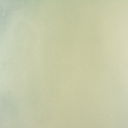
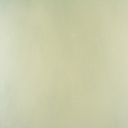
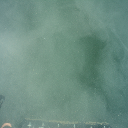
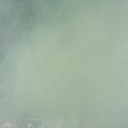
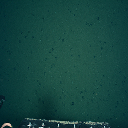
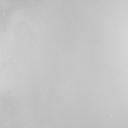
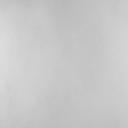
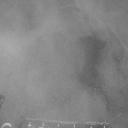
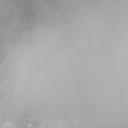
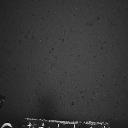
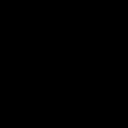
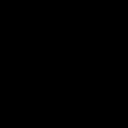
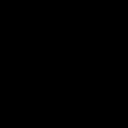
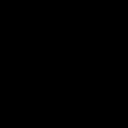
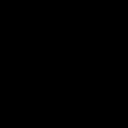

In [7]:
# See the images output
pipeline.images